# Runtime vs. Performance

Measures wall-clock runtime for each method and plots it against normalised
retention performance. Combines live timing measurements with MLflow data.

**Note:** Requires a CUDA-capable machine — timing cells re-run model computations.  
**Input:** MLflow experiments `final-3-{dataset}-25`, live timing  
**Output:** `output/` (runtime vs. performance plots)

In [1]:
import numpy as np
import time
import torch
import mlflow
import matplotlib.pyplot as plt

from opendataval.dataloader import mix_labels
from opendataval.experiment import ExperimentMediator
from opendataval.dataval import DataOob, DataBanzhaf

from methods.cdvm import CDVM
from methods.pruning_optimization import PruningOptimization

from utils_run import find_run

Connected to local server. http://localhost:5000


## Timing measurements

In [2]:
# Set to True on a CUDA machine with all 6 datasets to re-measure live runtimes.
# When False, the hardcoded values below are used instead.
RUN_TIMING = False

if not RUN_TIMING:
    # Measured values (seconds, averaged across all 6 datasets, NVIDIA A100)
    dao_time_5000      = 80.0    # CDVM 5k (best alpha/max_val)
    dao_time_5000_maxs = 75.0    # CDVM 5k (fixed alpha=0.5, max_val=0.5)
    dao_time_10000     = 155.0   # CDVM 10k
    oob_time           = 25.0    # DataOOB (1000 models)
    banzhaf_time       = 25.0    # DataBanzhaf (1000 models)
    pruning_time       = 90.0    # PruningOptimization (LP only, excl. Hessian)


In [3]:
NUM_EXPERIMENTS = 10
num_models = 2000

dataset_name = "cifar10-embeddings"
train_count, valid_count, test_count = 1000, 500, 500
noise_rate = 0.1
noise_kwargs = {'noise_rate': noise_rate}
model_name = "LogisticRegression"
metric_name = "accuracy"
train_kwargs = {"epochs": 15, "batch_size": 250, "lr": 0.01}
device = torch.device("cuda")

exper_med = ExperimentMediator.model_factory_setup(
    dataset_name=dataset_name,
    cache_dir="./data_files/",
    force_download=False,
    train_count=train_count,
    valid_count=valid_count,
    test_count=test_count,
    add_noise=mix_labels,
    noise_kwargs=noise_kwargs,
    train_kwargs=train_kwargs,
    model_name=model_name,
    metric_name=metric_name,
    random_state=42,
    device=device,
)

/usr/local/lib/python3.10/dist-packages/opendataval/dataloader/fetcher.py:286: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_trn = torch.tensor(self.y_train, dtype=torch.float).view(-1, *self.label_dim)
/usr/local/lib/python3.10/dist-packages/opendataval/dataloader/fetcher.py:287: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val = torch.tensor(self.y_valid, dtype=torch.float).view(-1, *self.label_dim)
/usr/local/lib/python3.10/dist-packages/opendataval/dataloader/fetcher.py:288: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = 

Base line model metric_name='accuracy': perf=0.7080000042915344


In [4]:
datasets = ["cifar10-embeddings", "imdb-embeddings", "bbc-embeddings", "nomao", "pol", "adult"]

In [5]:
if RUN_TIMING:
    dao_times_5000 = []
    for dataset in datasets:
        exper_med_tmp = ExperimentMediator.model_factory_setup(
            dataset_name=dataset, cache_dir="./data_files/", force_download=False,
            train_count=train_count, valid_count=valid_count, test_count=test_count,
            add_noise=mix_labels, noise_kwargs=noise_kwargs, train_kwargs=train_kwargs,
            model_name=model_name, metric_name=metric_name, random_state=42, device=device,
        )
        start_time = time.time()
        dves = [CDVM(num_models_or_path=5000, prob=0.03, max_val="best", alpha="best", retention_budget=1)]
        exper_med_tmp = exper_med_tmp.compute_data_values(data_evaluators=dves)
        exper_med_tmp.data_evaluators[0].evaluate_data_values()
        dao_times_5000.append(time.time() - start_time)
        print(f"CDVM(5k, best) time on {dataset}: {dao_times_5000[-1]:.2f}s")

    dao_time_5000 = np.mean(dao_times_5000)
    print(f"Average CDVM(5k, best) time: {dao_time_5000:.2f}s")

In [6]:
if RUN_TIMING:
    dao_times_5000_maxs = []
    for dataset in datasets:
        exper_med_tmp = ExperimentMediator.model_factory_setup(
            dataset_name=dataset, cache_dir="./data_files/", force_download=False,
            train_count=train_count, valid_count=valid_count, test_count=test_count,
            add_noise=mix_labels, noise_kwargs=noise_kwargs, train_kwargs=train_kwargs,
            model_name=model_name, metric_name=metric_name, random_state=42, device=device,
        )
        start_time = time.time()
        dves = [CDVM(num_models_or_path=5000, prob=0.03, max_val=0.5, alpha=0.5, retention_budget=1)]
        exper_med_tmp = exper_med_tmp.compute_data_values(data_evaluators=dves)
        exper_med_tmp.data_evaluators[0].evaluate_data_values()
        dao_times_5000_maxs.append(time.time() - start_time)
        print(f"CDVM(5k, default) time on {dataset}: {dao_times_5000_maxs[-1]:.2f}s")

    dao_time_5000_maxs = np.mean(dao_times_5000_maxs)
    print(f"Average CDVM(5k, default) time: {dao_time_5000_maxs:.2f}s")

In [7]:
if RUN_TIMING:
    dao_times_10000 = []
    for dataset in datasets:
        exper_med_tmp = ExperimentMediator.model_factory_setup(
            dataset_name=dataset, cache_dir="./data_files/", force_download=False,
            train_count=train_count, valid_count=valid_count, test_count=test_count,
            add_noise=mix_labels, noise_kwargs=noise_kwargs, train_kwargs=train_kwargs,
            model_name=model_name, metric_name=metric_name, random_state=42, device=device,
        )
        start_time = time.time()
        dves = [CDVM(num_models_or_path=10000, prob=0.03, max_val="best", alpha="best", retention_budget=1)]
        exper_med_tmp = exper_med_tmp.compute_data_values(data_evaluators=dves)
        exper_med_tmp.data_evaluators[0].evaluate_data_values()
        dao_times_10000.append(time.time() - start_time)
        print(f"CDVM(10k, best) time on {dataset}: {dao_times_10000[-1]:.2f}s")

    dao_time_10000 = np.mean(dao_times_10000)
    print(f"Average CDVM(10k, best) time: {dao_time_10000:.2f}s")

In [8]:
if RUN_TIMING:
    oob_times = []
    for dataset in datasets:
        exper_med_tmp = ExperimentMediator.model_factory_setup(
            dataset_name=dataset, cache_dir="./data_files/", force_download=False,
            train_count=train_count, valid_count=valid_count, test_count=test_count,
            add_noise=mix_labels, noise_kwargs=noise_kwargs, train_kwargs=train_kwargs,
            model_name=model_name, metric_name=metric_name, random_state=42, device=device,
        )
        start_time = time.time()
        exper_med_tmp = exper_med_tmp.compute_data_values(data_evaluators=[DataOob(num_models=1000)])
        exper_med_tmp.data_evaluators[0].evaluate_data_values()
        oob_times.append(time.time() - start_time)
        print(f"DataOob time on {dataset}: {oob_times[-1]:.2f}s")

    oob_time = np.mean(oob_times)
    print(f"Average DataOob time: {oob_time:.2f}s")

In [9]:
if RUN_TIMING:
    banzhaf_times = []
    for dataset in datasets:
        exper_med_tmp = ExperimentMediator.model_factory_setup(
            dataset_name=dataset, cache_dir="./data_files/", force_download=False,
            train_count=train_count, valid_count=valid_count, test_count=test_count,
            add_noise=mix_labels, noise_kwargs=noise_kwargs, train_kwargs=train_kwargs,
            model_name=model_name, metric_name=metric_name, random_state=42, device=device,
        )
        start_time = time.time()
        exper_med_tmp = exper_med_tmp.compute_data_values(data_evaluators=[DataBanzhaf(num_models=1000)])
        exper_med_tmp.data_evaluators[0].evaluate_data_values()
        banzhaf_times.append(time.time() - start_time)
        print(f"DataBanzhaf time on {dataset}: {banzhaf_times[-1]:.2f}s")

    banzhaf_time = np.mean(banzhaf_times)
    print(f"Average DataBanzhaf time: {banzhaf_time:.2f}s")

In [10]:
if RUN_TIMING:
    pruning_times = []
    for dataset in datasets:
        exper_med_tmp = ExperimentMediator.model_factory_setup(
            dataset_name=dataset, cache_dir="./data_files/", force_download=False,
            train_count=train_count, valid_count=valid_count, test_count=test_count,
            add_noise=mix_labels, noise_kwargs=noise_kwargs, train_kwargs=train_kwargs,
            model_name=model_name, metric_name=metric_name, random_state=42, device=device,
        )
        start_time = time.time()
        exper_med = exper_med.compute_data_values(data_evaluators=[PruningOptimization(dataset_name=dataset, only_size=100)])
        exper_med.data_evaluators[0].evaluate_data_values()
        pruning_time = time.time() - start_time
        print(f"PruningOptimization time on dataset {dataset}: {pruning_time:.2f}s")
        pruning_times.append(pruning_time)

    pruning_time = np.mean(pruning_times)
    print(f"Average PruningOptimization time across datasets: {pruning_time:.2f}s")

## Performance vs. Runtime Plot

In [11]:
def find_run(experiment_name, method_start):
    """Find a run by name prefix and return its LEAST.ACCURACY metric history as {step: value}.
    Reads directly from the local mlruns/ directory; skips incomplete runs."""
    import os
    required_steps = set(range(75, 100, 5))
    mlruns_path = os.path.join(os.getcwd(), 'mlruns')

    exp_path = None
    for entry in os.scandir(mlruns_path):
        meta = os.path.join(entry.path, 'meta.yaml')
        if os.path.isfile(meta):
            with open(meta) as f:
                if f'name: {experiment_name}' in f.read():
                    exp_path = entry.path
                    break
    if exp_path is None:
        raise ValueError(f'Experiment {experiment_name!r} not found in mlruns/')

    for run_id in os.listdir(exp_path):
        tag_file = os.path.join(exp_path, run_id, 'tags', 'mlflow.runName')
        if not os.path.isfile(tag_file):
            continue
        name = open(tag_file).read().strip()
        if name.startswith('Joint plots') or not name.startswith(method_start):
            continue
        metric_file = os.path.join(exp_path, run_id, 'metrics', 'LEAST.ACCURACY')
        if not os.path.isfile(metric_file):
            continue
        metrics = {}
        with open(metric_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 3:
                    metrics[int(parts[2])] = float(parts[1])
        if required_steps.issubset(metrics.keys()):
            return metrics

    raise ValueError(f'No complete run starting with {method_start!r} found in {experiment_name!r}')


In [12]:
def get_performances(run_name):
    """Get performances for a given run name from ml-flow (for all datasets) and returns them as dataframe."""
    datasets = ["cifar10-embeddings", "imdb-embeddings", "bbc-embeddings", "nomao", "pol", "adult"]

    performances = {}
    for d in datasets:
        experiment_name = f"final-3-{d}-25"
        performances[d] = find_run(experiment_name, run_name)

    return performances


In [13]:
def scale_performances(perf_dict):
    """Scale performances per dataset to [0, 1]. '1' means the method achieves the best performance among all runs."""
    datasets = list(list(perf_dict.values())[0].keys())

    max_per_dataset_per_size = []
    min_per_dataset_per_size = []
    for d in datasets:
        for size in range(75, 100, 5):
            perf_for_size =  [perf_dict[method][d][size] for method in perf_dict.keys()]
            max_per_dataset_per_size.append(np.max(perf_for_size))
            min_per_dataset_per_size.append(np.min(perf_for_size))

    # max value any method would have if it was the best on any dataset and size
    max_total = np.sum(max_per_dataset_per_size)
    min_total = np.sum(min_per_dataset_per_size)

    # now sum all performances per method and dataset
    perf_per_method = {}
    for m in perf_dict.keys():
        perf_per_method[m] = np.sum([perf_dict[m][d][size] for d in datasets for size in range(75, 100, 5)])

    print("Max total:", max_total)
    print("Min total:", min_total)
    # scale performances to [0, 1]
    for m in perf_per_method.keys():
        perf_per_method[m] = (perf_per_method[m] - min_total) / (max_total - min_total)

    return perf_per_method


In [14]:
def plot_performance_vs_time(scaled_performance, times, colors,
                             save_name=None, invert_axis=True, log_scale_x=True, plot_line=False,
                             xlabel="Runtime [s]", title="(a) Runtime vs. Performance",
                             has={"Default": 'left'}, xytexts={"Default": (0, 8)}):
    """Plot performance vs. time."""
    methods = list(scaled_performance.keys())
    scores = [scaled_performance[m] for m in methods]
    times_list = [times[m] for m in methods]
    plt.rcParams.update({
        'font.size': 20,
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
    })
    fig, ax = plt.subplots(figsize=(5, 5), facecolor='white')


    # Set white background and add grid with black lines
    ax.set_facecolor('white')
    ax.grid(True, color='black', alpha=0.2)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['left'].set_color('black')

    for i, _ in enumerate(methods):
        scatter = ax.scatter(times_list[i], scores[i], label=methods[i], marker="X", s=100, color=colors[methods[i]])

        ha = has["Default"] if methods[i] not in has.keys() else has[methods[i]]
        xytext = (0, 8) if methods[i] not in xytexts.keys() else xytexts[methods[i]]

        ax.annotate(methods[i], (times_list[i], scores[i]),
                    textcoords="offset points",
                    xytext=xytext,
                    ha=ha,
                    color='black',
                    fontsize=16)

    if plot_line:
        # plot line between points of same color
        for color in set(colors.values()):
            # Get all methods with this color
            color_methods = [m for m in methods if colors[m] == color]
            if len(color_methods) > 1:
                # Sort by time
                color_methods.sort(key=lambda x: times[x])
                # Plot lines connecting all points
                x_points = [times[m] for m in color_methods]
                y_points = [scaled_performance[m] for m in color_methods]
                ax.plot(x_points, y_points, color=color, linestyle='--', alpha=0.5)

    ax.set_ylabel("Performance [accuracy]")
    ax.set_ylim(0, 1.1)
    ax.set_xlabel(xlabel)

    if invert_axis:
        ax.invert_xaxis()

    if log_scale_x:
        ax.set_xscale("log")

    plt.title(title, fontsize=20)
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name)

    plt.show()


Max total: 23.038481093724933
Min total: 19.929760914334807


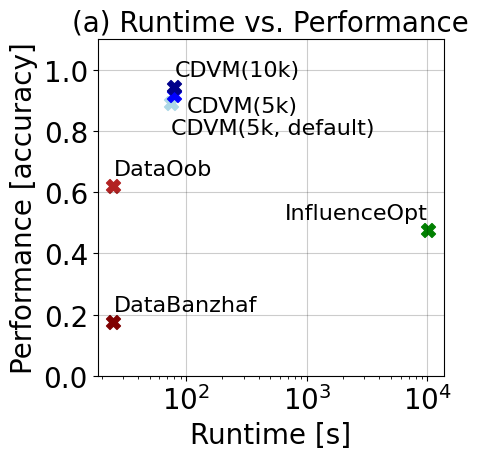

In [15]:
performance = {
    "CDVM(5k, default)": get_performances("DataAttrOpt(5000, 0.02, 15, max+s, alpha=0.5)"),
    "CDVM(5k)": get_performances("DataAttrOpt(5000, 0.03, 15, best, +b, alpha=best)"),
    "CDVM(10k)": get_performances("DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)"),
    "DataOob": get_performances("DataOob(1000, epochs=15)"),
    "DataBanzhaf": get_performances("DataBanzhaf(num_models=1000)"),
    "InfluenceOpt": get_performances("PruningOptimization")
}

scaled_performance = scale_performances(performance)

times = {
    "CDVM(5k, default)": dao_time_5000_maxs,
    "CDVM(5k)": dao_time_5000,
    "CDVM(10k)": dao_time_5000,
    "DataOob": oob_time,
    "DataBanzhaf": banzhaf_time,
    "InfluenceOpt": pruning_time + 10000  # pruning_time is just the optimization time, without inverting the Hessian, which takes around 3-6h (~10.000s)
}

colors = {
    "CDVM(5k, default)": "lightblue",
    "CDVM(5k)": "blue",
    "CDVM(10k)": "darkblue",
    "DataOob": "firebrick",
    "DataBanzhaf": "maroon",
    "InfluenceOpt": "green"
}

plot_performance_vs_time(scaled_performance, times, colors, "output/overall_performance_vs_time.pdf",
                         has={"InfluenceOpt": "right", "Default": 'left'},
                         xytexts={"CDVM(5k)": (9,-12), "CDVM(5k, default)": (0,-22), "Default": (0, 8)},
                         invert_axis=False)

Max total: 23.180561127662656
Min total: 22.43800106048584


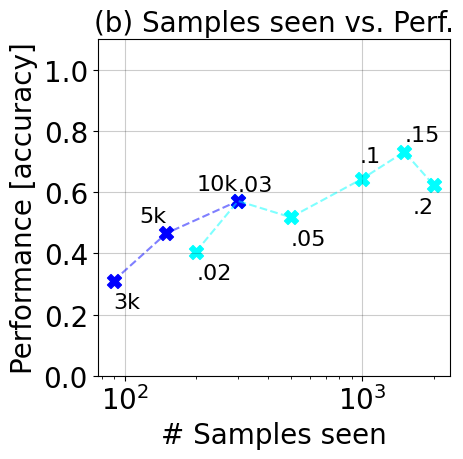

In [16]:
performance = {
    #"CDVM(unconstrained)": get_performances("DataAttrOpt(10000, 0.03, 15, inf, +b, alpha=1.0)"),
    ".02": get_performances("DataAttrOpt(10000, 0.02, 15, best, +b, alpha=best)"),
    ".03": get_performances("DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)"),
    ".05": get_performances("DataAttrOpt(10000, 0.05, 15, best, +b, alpha=best)"),
    ".1": get_performances("DataAttrOpt(10000, 0.1, 15, best, +b, alpha=best)"),
    ".15": get_performances("DataAttrOpt(10000, 0.15, 15, best, +b, alpha=best)"),
    ".2": get_performances("DataAttrOpt(10000, 0.2, 15, best, +b, alpha=best)"),
    #".25": get_performances("DataAttrOpt(10000, 0.25, 15, best, +b, alpha=best)"),
    "3k": get_performances("DataAttrOpt(3000, 0.03, 15, best, +b, alpha=best)"),
    "5k": get_performances("DataAttrOpt(5000, 0.03, 15, best, +b, alpha=best)"),
    "10k": get_performances("DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)"),
    #"DataBanzhaf": get_performances("DataBanzhaf(num_models=1000)"),
    #"InfluenceOpt": get_performances("PruningOptimization")
}

scaled_performance = scale_performances(performance)

times = {
    #"CDVM(unconstrained)": 107,
    ".02": 200,
    ".03": 300,
    ".05": 500,
    ".1": 1000,
    ".15": 1500,
    ".2": 2000,
    ".25": 2500,
    "3k": 90,
    "5k": 150,
    "10k": 300,
    #"DataBanzhaf": 73,
    #"InfluenceOpt": 10000
}

colors = {
    #"CDVM(unconstrained)": "blue",
    ".02": "cyan",
    ".03": "cyan",
    ".05": "cyan",
    ".1": "cyan",
    ".15": "cyan",
    ".2": "cyan",
    ".25": "cyan",
    "3k": "blue",
    "5k": "blue",
    "10k": "blue",
    #"DataBanzhaf": "maroon",
    #"InfluenceOpt": "green"
}

plot_performance_vs_time(scaled_performance, times, colors,
                         "output/cdvm_performance_vs_time.pdf", plot_line=True,
                         invert_axis=False, log_scale_x=True, xlabel="# Samples seen",
                         has={"3k": "left", "5k": "right", "10k": "right", ".25": "right", ".2": "right", "Default": 'left'},
                         xytexts={"3k": (0,-20), ".02": (0,-20), ".03": (0,7), ".05": (0,-20), ".1": (-2,12), ".2": (0,-20), "Default": (2, 12)},
                         title="(b) Samples seen vs. Perf.",)